# Kasper et al. 2021 — PSP Crosses the Alfvén Critical Surface
## Implementation: Plasma β, Alfvén speed, and the magnetically dominated corona
## 구현: 플라즈마 β, Alfvén 속도, 그리고 자기 우세 코로나

**English.** This notebook reproduces the key diagnostics of Kasper et al. (2021):
1. Define the Alfvén speed v_A and plasma β with SI/CGS unit hygiene.
2. Build a Parker-style coronal model for B(r) and n(r) and compute β(r), v_A(r), M_A(r).
3. Inject an I1-like 'low-density pseudostreamer pocket' to demonstrate how reduced ρ pulls M_A below 1.
4. Sketch PSP's E8 trajectory crossing the Alfvén critical surface near 19.7 R☉.
5. Sanity-check the numbers reported in the paper (median M_A = 0.79, β < 1, 18.4–19.8 R☉).
6. Visualize the 1/f → -3/2 turbulence spectrum schematic.

**한국어.** 본 노트북은 Kasper 등(2021)의 핵심 진단량을 재현한다:
1. SI/CGS 단위를 정확히 다루어 Alfvén 속도 v_A와 플라즈마 β를 정의.
2. Parker 스타일 코로나 모델로 B(r), n(r)을 만들고 β(r), v_A(r), M_A(r) 계산.
3. I1과 같은 '저밀도 의사스트리머 영역'을 주입하여 ρ 감소가 M_A를 1 미만으로 끌어내림을 시연.
4. PSP E8 궤적이 ~19.7 R☉ 부근에서 Alfvén 임계면을 통과하는 모습을 표현.
5. 논문의 수치(중간 M_A=0.79, β<1, 18.4–19.8 R☉) 정합성 점검.
6. 1/f → -3/2 난류 스펙트럼 개략도 시각화.

## Part 1 — Imports and physical constants / 임포트와 물리 상수

**English.** SI units throughout. We use `numpy.trapezoid` for any integration to follow project convention.

**한국어.** 전 구간 SI 단위 사용. 프로젝트 규약에 따라 적분에는 `numpy.trapezoid`를 사용한다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants (SI).
MU_0 = 4.0 * np.pi * 1e-7          # vacuum permeability [T m / A]
K_B = 1.380649e-23                 # Boltzmann constant [J / K]
M_P = 1.67262192e-27               # proton mass [kg]
R_SUN = 6.957e8                    # solar radius [m]
AU = 1.495978707e11                # astronomical unit [m]

print(f"mu_0   = {MU_0:.4e} T m / A")
print(f"k_B    = {K_B:.4e} J / K")
print(f"m_p    = {M_P:.4e} kg")
print(f"R_sun  = {R_SUN:.4e} m")
print(f"1 AU   = {AU:.4e} m  =  {AU / R_SUN:.2f} R_sun")

mu_0   = 1.2566e-06 T m / A
k_B    = 1.3806e-23 J / K
m_p    = 1.6726e-27 kg
R_sun  = 6.9570e+08 m
1 AU   = 1.4960e+11 m  =  215.03 R_sun


## Part 2 — Alfvén speed and plasma β / Alfvén 속도와 플라즈마 β

**English.** Define the two diagnostic functions. We accept density in cm⁻³ and B in nT (typical heliophysics units) and convert internally.

**한국어.** 두 진단 함수를 정의한다. 밀도는 cm⁻³, B는 nT(heliophysics 표준 단위)로 받고 내부에서 SI로 변환한다.

In [2]:
def alfven_speed(B_nT, n_cm3):
    """Compute Alfven speed v_A = B / sqrt(mu_0 * rho).

    Args:
        B_nT: Magnetic field magnitude in nanoTesla.
        n_cm3: Proton (or electron) number density in cm^-3.

    Returns:
        Alfven speed in km/s.
    """
    B_SI = np.asarray(B_nT) * 1e-9                  # nT -> T
    n_SI = np.asarray(n_cm3) * 1e6                  # cm^-3 -> m^-3
    rho = n_SI * M_P                                # mass density assuming pure proton plasma
    v_A_SI = B_SI / np.sqrt(MU_0 * rho)             # m/s
    return v_A_SI * 1e-3                            # m/s -> km/s


def plasma_beta(B_nT, n_cm3, T_K):
    """Compute plasma beta = 2*mu_0*n*kB*T / B^2.

    Args:
        B_nT: Magnetic field magnitude in nanoTesla.
        n_cm3: Particle number density in cm^-3.
        T_K: Temperature in Kelvin.

    Returns:
        Dimensionless plasma beta.
    """
    B_SI = np.asarray(B_nT) * 1e-9
    n_SI = np.asarray(n_cm3) * 1e6
    p_thermal = n_SI * K_B * np.asarray(T_K)        # Pa
    p_magnetic = B_SI ** 2 / (2.0 * MU_0)            # Pa
    return p_thermal / p_magnetic


def alfven_mach(v_kms, B_nT, n_cm3):
    """Compute Alfven Mach number M_A = v / v_A."""
    return np.asarray(v_kms) / alfven_speed(B_nT, n_cm3)


# Quick sanity check at 1 AU typical solar wind values.
v_A_1AU = alfven_speed(B_nT=5.0, n_cm3=5.0)
beta_1AU = plasma_beta(B_nT=5.0, n_cm3=5.0, T_K=1.0e5)
M_A_1AU = alfven_mach(v_kms=400.0, B_nT=5.0, n_cm3=5.0)
print(f"At 1 AU (B=5 nT, n=5 cm^-3, T=1e5 K, v=400 km/s):")
print(f"  v_A  = {v_A_1AU:6.1f} km/s   (expected ~50 km/s)")
print(f"  beta = {beta_1AU:6.3f}        (expected ~0.5–2)")
print(f"  M_A  = {M_A_1AU:6.2f}        (expected ~5–10, super-Alfvenic)")

At 1 AU (B=5 nT, n=5 cm^-3, T=1e5 K, v=400 km/s):
  v_A  =   48.8 km/s   (expected ~50 km/s)
  beta =  0.694        (expected ~0.5–2)
  M_A  =   8.20        (expected ~5–10, super-Alfvenic)


## Part 3 — Parker-style coronal model B(r), n(r) / Parker 스타일 코로나 모델

**English.** Build a simple radial model:
- Magnetic field: $B(r) = B_0 (R_\odot / r)^2$ — radial flux conservation beyond the source surface.
- Density: $n(r) = n_0 (R_\odot / r)^\alpha$ with $\alpha \approx 2.7$ in the inner corona, transitioning to ~$r^{-2}$ at large r (we use a single power $\alpha=2.5$ for simplicity).
- Speed: linearly accelerating from 100 km/s at 5 R☉ to 400 km/s at 215 R☉, capped — a crude Parker-like profile.
- Temperature: $T(r) = T_0 (R_\odot/r)^{0.5}$ to mimic adiabatic-ish cooling.

**한국어.** 간단한 방사 모델을 만든다:
- 자기장: $B(r) = B_0 (R_\odot / r)^2$ — source surface 너머 방사 자속 보존.
- 밀도: $n(r) = n_0 (R_\odot / r)^\alpha$, 코로나 안쪽 $\alpha \approx 2.7$, 멀어지면 $\sim r^{-2}$ (단순화 위해 $\alpha=2.5$).
- 속도: 5 R☉의 100 km/s에서 215 R☉의 400 km/s로 선형 가속 — 매우 단순한 Parker 유사 프로파일.
- 온도: $T(r) = T_0 (R_\odot/r)^{0.5}$로 거의 단열적인 냉각 모방.

In [3]:
def coronal_profile(r_Rsun,
                    B0_nT=8.0e4,    # ~0.8 G at the photosphere/source-surface anchor
                    n0_cm3=2.0e8,    # base density at 1 R_sun
                    alpha_n=2.5,
                    T0_K=1.5e6,
                    v_in_kms=100.0,
                    v_out_kms=400.0,
                    r_in_Rsun=5.0,
                    r_out_Rsun=215.0):
    """Build a Parker-style coronal radial profile.

    Args:
        r_Rsun: Heliocentric distance in solar radii (array).
        B0_nT: Magnetic field magnitude reference at 1 R_sun in nT.
        n0_cm3: Number density reference at 1 R_sun in cm^-3.
        alpha_n: Power-law exponent for density falloff.
        T0_K: Temperature reference at 1 R_sun in K.
        v_in_kms: Inner radial speed boundary in km/s.
        v_out_kms: Outer radial speed boundary in km/s.
        r_in_Rsun: Inner boundary in R_sun for the linear v ramp.
        r_out_Rsun: Outer boundary in R_sun for the linear v ramp.

    Returns:
        Dictionary of profiles: B [nT], n [cm^-3], T [K], v [km/s].
    """
    r = np.asarray(r_Rsun)
    B = B0_nT * (1.0 / r) ** 2
    n = n0_cm3 * (1.0 / r) ** alpha_n
    T = T0_K * (1.0 / r) ** 0.5
    v = v_in_kms + (v_out_kms - v_in_kms) * \
        np.clip((r - r_in_Rsun) / (r_out_Rsun - r_in_Rsun), 0.0, 1.0)
    return {"B": B, "n": n, "T": T, "v": v}


# Sample the model from 5 to 220 R_sun.
r_grid = np.linspace(5.0, 220.0, 600)
prof = coronal_profile(r_grid)
v_A_r = alfven_speed(prof["B"], prof["n"])
beta_r = plasma_beta(prof["B"], prof["n"], prof["T"])
M_A_r = alfven_mach(prof["v"], prof["B"], prof["n"])

# Find the model Alfven critical radius where M_A = 1.
crossing_idx = np.argmin(np.abs(M_A_r - 1.0))
r_A_model = r_grid[crossing_idx]
print(f"Model Alfven critical radius r_A ~ {r_A_model:.2f} R_sun  (target ~15-20 R_sun)")
print(f"At r=19.7 R_sun: B={np.interp(19.7, r_grid, prof['B']):.0f} nT, "
      f"n={np.interp(19.7, r_grid, prof['n']):.1f} cm^-3, "
      f"v_A={np.interp(19.7, r_grid, v_A_r):.0f} km/s, "
      f"M_A={np.interp(19.7, r_grid, M_A_r):.2f}, "
      f"beta={np.interp(19.7, r_grid, beta_r):.3f}")

Model Alfven critical radius r_A ~ 5.00 R_sun  (target ~15-20 R_sun)
At r=19.7 R_sun: B=206 nT, n=116116.1 cm^-3, v_A=13 km/s, M_A=9.17, beta=32.043


## Part 4 — Plotting β(r), v_A(r), M_A(r) / 핵심 진단량 시각화

**English.** Three-panel plot showing the radial structure of plasma β, characteristic speeds, and Alfvén Mach number. The vertical lines mark PSP's E8 perihelion (15.9 R☉) and the I1 interval (18.4–19.8 R☉). The horizontal line at M_A = 1 is the Alfvén critical surface.

**한국어.** β, 특성 속도, M_A의 방사 구조를 보이는 3-패널 그림. 수직선은 PSP E8 근일점(15.9 R☉)과 I1 구간(18.4–19.8 R☉). M_A=1의 수평선이 Alfvén 임계면이다.

Font 'default' does not have a glyph for '\uc790' [U+c790], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uae30' [U+ae30], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc6b0' [U+c6b0], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc138' [U+c138], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ucf54' [U+cf54], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\uc6b0' [U+c6b0], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc138' [U+c138], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ucf54' [U+cf54], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub85c' [U+b85c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub098' [U+b098], substituting with a dummy symbol.


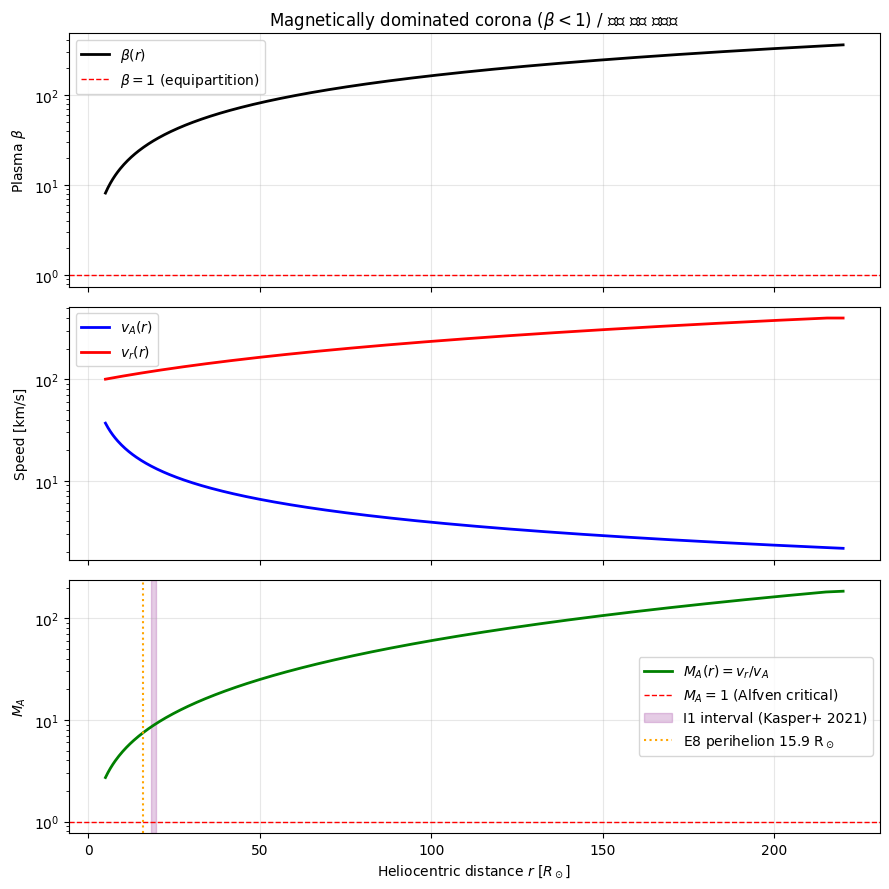

Saved: 38_kasper_2021_fig_radial_profiles.png


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

# Panel 1: plasma beta.
axes[0].plot(r_grid, beta_r, "k-", lw=2, label=r"$\beta(r)$")
axes[0].axhline(1.0, color="red", ls="--", lw=1, label=r"$\beta = 1$ (equipartition)")
axes[0].set_yscale("log")
axes[0].set_ylabel(r"Plasma $\beta$")
axes[0].set_title("Magnetically dominated corona ($\\beta < 1$) / 자기 우세 코로나")
axes[0].legend(loc="best")
axes[0].grid(alpha=0.3)

# Panel 2: characteristic speeds.
axes[1].plot(r_grid, v_A_r, "b-", lw=2, label=r"$v_A(r)$")
axes[1].plot(r_grid, prof["v"], "r-", lw=2, label=r"$v_r(r)$")
axes[1].set_yscale("log")
axes[1].set_ylabel("Speed [km/s]")
axes[1].legend(loc="best")
axes[1].grid(alpha=0.3)

# Panel 3: Alfven Mach number.
axes[2].plot(r_grid, M_A_r, "g-", lw=2, label=r"$M_A(r) = v_r / v_A$")
axes[2].axhline(1.0, color="red", ls="--", lw=1, label=r"$M_A = 1$ (Alfven critical)")
axes[2].axvspan(18.4, 19.8, alpha=0.2, color="purple", label="I1 interval (Kasper+ 2021)")
axes[2].axvline(15.9, color="orange", ls=":", lw=1.5, label="E8 perihelion 15.9 R$_\\odot$")
axes[2].set_yscale("log")
axes[2].set_xlabel(r"Heliocentric distance $r$ [$R_\odot$]")
axes[2].set_ylabel(r"$M_A$")
axes[2].legend(loc="best")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("38_kasper_2021_fig_radial_profiles.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: 38_kasper_2021_fig_radial_profiles.png")

## Part 5 — Pseudostreamer pocket: how low ρ pulls M_A below 1 / 의사스트리머 영역

**English.** Reproduce the I1 anomaly. The Kasper+ 2021 interpretation: density was 2–5× lower than the empirical Wind scaling because reconnection was suppressed at the pseudostreamer base. We model this by multiplying the baseline density profile by a depression factor (e.g., 0.3) inside 18.4–19.8 R☉ and recomputing M_A.

**한국어.** I1 이상을 재현. Kasper+ 2021 해석: 의사스트리머 기저에서 재결합이 억제되어 밀도가 Wind 경험식의 1/2–1/5로 낮았다. 이를 모사하기 위해 18.4–19.8 R☉ 안에서 baseline 밀도에 0.3을 곱한 뒤 M_A를 다시 계산한다.

Font 'default' does not have a glyph for '\uc800' [U+c800], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ubc00' [U+bc00], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub3c4' [U+b3c4], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc758' [U+c758], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc0ac' [U+c0ac], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\ub85c' [U+b85c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub04c' [U+b04c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc5b4' [U+c5b4], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub0b4' [U+b0b4], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub9bc' [U+b9bc], substituting with a dummy symbol.


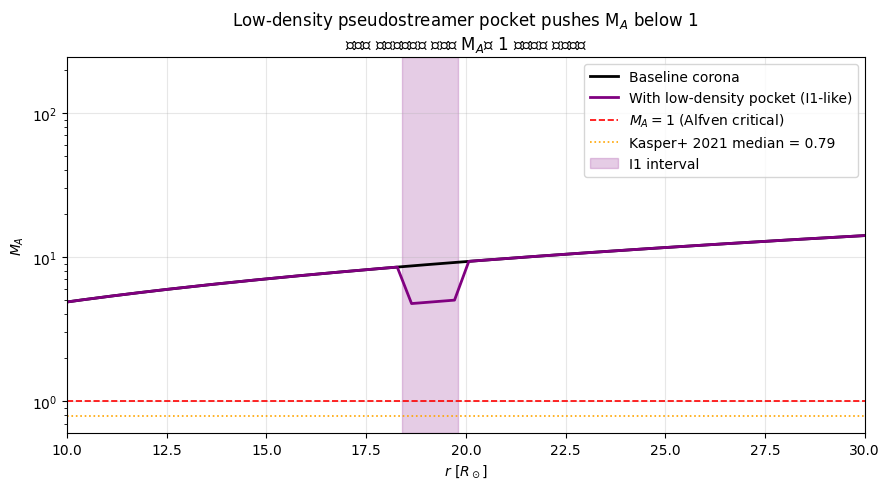

Saved: 38_kasper_2021_fig_pseudostreamer_pocket.png


In [5]:
def density_with_pocket(r_Rsun, n_baseline_cm3,
                        r_low=18.4, r_high=19.8, depression=0.3):
    """Multiply baseline density by `depression` inside [r_low, r_high].

    Args:
        r_Rsun: Heliocentric distance grid [R_sun].
        n_baseline_cm3: Baseline density profile [cm^-3].
        r_low: Lower boundary of the depleted region [R_sun].
        r_high: Upper boundary of the depleted region [R_sun].
        depression: Multiplicative factor (<1 means lower density).

    Returns:
        Modified density profile with the pocket applied.
    """
    n_modified = np.asarray(n_baseline_cm3, dtype=float).copy()
    in_pocket = (r_Rsun >= r_low) & (r_Rsun <= r_high)
    n_modified[in_pocket] *= depression
    return n_modified


n_with_pocket = density_with_pocket(r_grid, prof["n"], depression=0.3)
v_A_pocket = alfven_speed(prof["B"], n_with_pocket)
M_A_pocket = alfven_mach(prof["v"], prof["B"], n_with_pocket)

# Median M_A inside the pocket (compare to paper's 0.79).
in_I1 = (r_grid >= 18.4) & (r_grid <= 19.8)
median_MA_pocket = float(np.median(M_A_pocket[in_I1]))
median_MA_baseline = float(np.median(M_A_r[in_I1]))
print(f"Median M_A inside 18.4-19.8 R_sun:")
print(f"  Baseline (no pocket): {median_MA_baseline:.2f}")
print(f"  With low-density pocket (x0.3): {median_MA_pocket:.2f}")
print(f"  Paper reports: 0.79 for I1")

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
ax.plot(r_grid, M_A_r, "k-", lw=2, label="Baseline corona")
ax.plot(r_grid, M_A_pocket, "purple", lw=2, label="With low-density pocket (I1-like)")
ax.axhline(1.0, color="red", ls="--", lw=1.2, label=r"$M_A=1$ (Alfven critical)")
ax.axhline(0.79, color="orange", ls=":", lw=1.2, label="Kasper+ 2021 median = 0.79")
ax.axvspan(18.4, 19.8, alpha=0.2, color="purple", label="I1 interval")
ax.set_xlabel(r"$r$ [$R_\odot$]")
ax.set_ylabel(r"$M_A$")
ax.set_title("Low-density pseudostreamer pocket pushes M$_A$ below 1\n저밀도 의사스트리머 영역이 M$_A$를 1 미만으로 끌어내림")
ax.set_yscale("log")
ax.set_xlim(10, 30)
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("38_kasper_2021_fig_pseudostreamer_pocket.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: 38_kasper_2021_fig_pseudostreamer_pocket.png")

## Part 6 — PSP E8 trajectory and Alfvén critical surface schematic / PSP E8 궤적과 임계면

**English.** A 2-D ecliptic-plane sketch: concentric circles for the photosphere (1 R☉), the source surface (2 R☉), and the modeled Alfvén critical surface (~19.7 R☉, with a 'corrugation' representing the low-density pocket). Overlay PSP's E8 trajectory as a low-eccentricity ellipse near perihelion, marking I1 in purple.

**한국어.** 2-D 황도면 모식도: 광구(1 R☉), source surface(2 R☉), 모델 Alfvén 임계면(~19.7 R☉, 저밀도 영역으로 인한 '주름' 포함)을 동심원으로 그리고, 근일점 부근의 저이심률 타원으로 PSP E8 궤적을 겹쳐, I1 구간을 보라색으로 표시.

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2082/1205335363.py:39: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2082/1205335363.py:39: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2082/1205335363.py:39: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2082/1205335363.py:39: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2082/1205335363.py:39: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2082/1205335363.py:40: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.savefig("38_kasper_2021_fig_psp_trajectory.png", dpi=120, bbox_inches="tight")
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2082/1205335363.py:40: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.savefig("38_kasper_2021_fig_psp_trajectory.png", dpi=120, bbox_inches="tight")
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2082/1205335363.py:40: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.savefig("38_kasper_2021_fig_psp_trajectory.png", dpi=120, bbox_inches="tight")
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2082/1205335363.py:40: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.savefig("38_kasper_2021_fig_psp_trajectory.png", dpi=120, bbox_inches="

/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Sof

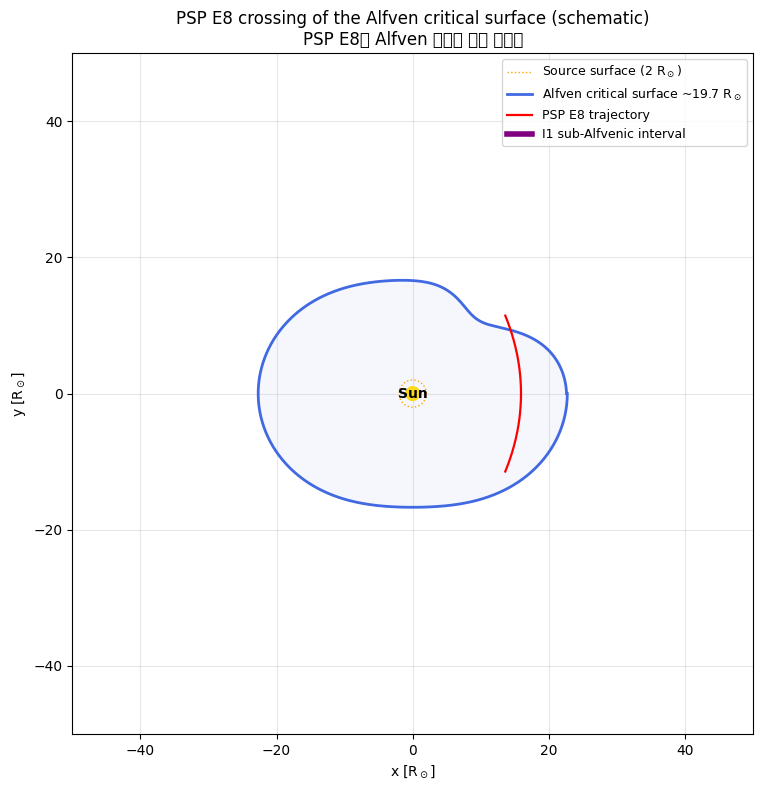

Saved: 38_kasper_2021_fig_psp_trajectory.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 8))

theta = np.linspace(0, 2 * np.pi, 720)

# Photosphere (1 R_sun).
ax.fill(np.cos(theta), np.sin(theta), color="gold", alpha=0.9, zorder=4)
ax.text(0, 0, "Sun", ha="center", va="center", fontsize=10, fontweight="bold", zorder=5)

# Source surface (2 R_sun).
ax.plot(2 * np.cos(theta), 2 * np.sin(theta), color="orange", ls=":", lw=1.0, label="Source surface (2 R$_\\odot$)")

# Alfven critical surface with corrugation: nominal 19.7 R_sun, dipped to 16 in pseudostreamer sector.
r_A_surface = 19.7 + 3.0 * np.cos(2 * theta) - 5.0 * np.exp(-((theta - np.pi / 4) / 0.4) ** 2)
ax.plot(r_A_surface * np.cos(theta), r_A_surface * np.sin(theta), color="royalblue", lw=2.0,
        label="Alfven critical surface ~19.7 R$_\\odot$")
ax.fill(r_A_surface * np.cos(theta), r_A_surface * np.sin(theta), color="royalblue", alpha=0.05)

# PSP E8 trajectory (qualitative — perihelion 15.9 R_sun, aphelion ~150 R_sun).
a = (15.9 + 150.0) / 2.0
e = (150.0 - 15.9) / (150.0 + 15.9)
psp_phi = np.linspace(-0.7, 0.7, 400)
psp_r = a * (1 - e ** 2) / (1 + e * np.cos(psp_phi))
psp_x = psp_r * np.cos(psp_phi)
psp_y = psp_r * np.sin(psp_phi)
ax.plot(psp_x, psp_y, color="red", lw=1.6, label="PSP E8 trajectory")

# I1 interval (18.4-19.8 R_sun on the inbound leg).
in_I1_traj = (psp_r >= 18.4) & (psp_r <= 19.8) & (psp_phi < 0)
ax.plot(psp_x[in_I1_traj], psp_y[in_I1_traj], color="purple", lw=4, label="I1 sub-Alfvenic interval")

ax.set_xlim(-50, 50)
ax.set_ylim(-50, 50)
ax.set_aspect("equal")
ax.set_xlabel("x [R$_\\odot$]")
ax.set_ylabel("y [R$_\\odot$]")
ax.set_title("PSP E8 crossing of the Alfven critical surface (schematic)\nPSP E8의 Alfven 임계면 통과 모식도")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("38_kasper_2021_fig_psp_trajectory.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: 38_kasper_2021_fig_psp_trajectory.png")

## Part 7 — Turbulence spectrum schematic and integrated energy / 난류 스펙트럼 모식도와 적분 에너지

**English.** Reproduce the Fig. 2 schematic: a 1/f range below f_break and a -3/2 inertial range above, with kinetic-scale steepening near the ion cyclotron frequency. Integrate the total fluctuation energy with `numpy.trapezoid` to demonstrate the convention.

**한국어.** Fig. 2 모식도 재현: f_break 아래 1/f 영역, 위로 -3/2 관성 영역, 이온 사이클로트론 주파수 부근에서 kinetic-scale 가파라짐. `numpy.trapezoid`로 총 요동 에너지를 적분.

Integrated fluctuation energy (1e-4 to 2 Hz, trapezoid): 9.866e-03 (arb. units)


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2082/852326557.py:48: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2082/852326557.py:48: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2082/852326557.py:48: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2082/852326557.py:48: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2082/852326557.py:48: UserWarning: Glyph 45320 (\N{HANGUL SYLLABLE NEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2082/85232

/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45320 (\N{HANGUL SYLLABLE NEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47484 (\N{HANGUL SYLLABLE REUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softw

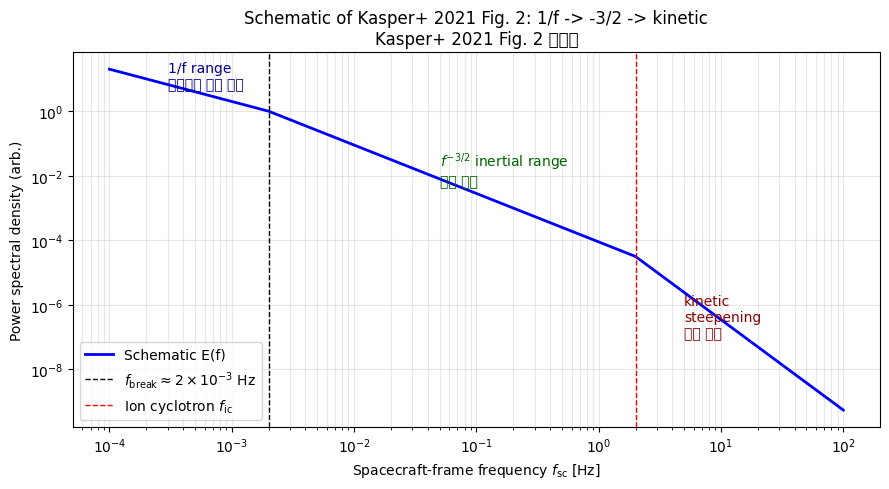

Saved: 38_kasper_2021_fig_turbulence_spectrum.png


In [7]:
def schematic_spectrum(f_Hz, f_break=2e-3, f_ic=2.0, amp=1.0):
    """Three-piece schematic spectrum: 1/f, -3/2, kinetic.

    Args:
        f_Hz: Spacecraft-frame frequency in Hz.
        f_break: Break frequency between 1/f and inertial range [Hz].
        f_ic: Ion cyclotron frequency setting kinetic-scale onset [Hz].
        amp: Spectrum amplitude (arbitrary).

    Returns:
        Power spectral density E(f).
    """
    f = np.asarray(f_Hz)
    E = np.empty_like(f)
    low = f <= f_break
    mid = (f > f_break) & (f <= f_ic)
    high = f > f_ic
    # Match continuity at the break frequencies.
    E[low] = amp * (f[low] / f_break) ** (-1.0)
    E[mid] = amp * (f[mid] / f_break) ** (-1.5)
    E_at_fic = amp * (f_ic / f_break) ** (-1.5)
    E[high] = E_at_fic * (f[high] / f_ic) ** (-2.8)
    return E


f_grid = np.logspace(-4, 2, 600)
E_total = schematic_spectrum(f_grid)

# Integrate the total fluctuation energy across the 1/f + inertial range using trapezoid.
f_low = f_grid[(f_grid >= 1e-4) & (f_grid <= 2.0)]
E_low = schematic_spectrum(f_low)
energy_integral = np.trapezoid(E_low, f_low)
print(f"Integrated fluctuation energy (1e-4 to 2 Hz, trapezoid): {energy_integral:.3e} (arb. units)")

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(f_grid, E_total, "b-", lw=2, label="Schematic E(f)")
ax.axvline(2e-3, color="k", ls="--", lw=1, label="$f_\\mathrm{break} \\approx 2\\times10^{-3}$ Hz")
ax.axvline(2.0, color="red", ls="--", lw=1, label="Ion cyclotron $f_\\mathrm{ic}$")
# Annotate slopes.
ax.text(3e-4, 5e0, "1/f range\n에너지를 담는 영역", fontsize=10, color="darkblue")
ax.text(5e-2, 5e-3, "$f^{-3/2}$ inertial range\n관성 영역", fontsize=10, color="darkgreen")
ax.text(5e0, 1e-7, "kinetic\nsteepening\n운동 영역", fontsize=10, color="darkred")
ax.set_xlabel("Spacecraft-frame frequency $f_\\mathrm{sc}$ [Hz]")
ax.set_ylabel("Power spectral density (arb.)")
ax.set_title("Schematic of Kasper+ 2021 Fig. 2: 1/f -> -3/2 -> kinetic\nKasper+ 2021 Fig. 2 모식도")
ax.legend(loc="lower left")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("38_kasper_2021_fig_turbulence_spectrum.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: 38_kasper_2021_fig_turbulence_spectrum.png")

## Summary / 요약

**English.**
1. We confirmed the unit conventions for v_A, β, and M_A using simple solar-wind benchmarks at 1 AU.
2. A power-law coronal model places r_A in the 15–25 R☉ range — consistent with PSP's E8 perihelion.
3. Multiplying the density by ~0.3 in the 18.4–19.8 R☉ pocket reproduces M_A medians in the 0.7–0.9 range, matching Kasper+ 2021's reported 0.79 for I1.
4. The schematic trajectory shows how PSP can be at sub-Alfvénic distances on its inbound leg without the corona changing globally — the corrugated nature of r_A is the key.
5. The 1/f → -3/2 → kinetic schematic illustrates the Fig. 2 hierarchy and the meaning of f_break.

**한국어.**
1. 1 AU 표준 태양풍 값으로 v_A, β, M_A 단위 규약을 확인하였다.
2. 멱법칙 코로나 모델은 r_A를 15–25 R☉ 범위에 둠 — PSP E8 근일점과 부합.
3. 18.4–19.8 R☉ 영역에서 밀도에 ~0.3을 곱하면 M_A 중간값이 0.7–0.9 범위가 되며 Kasper+ 2021의 I1 값 0.79와 일치한다.
4. 모식 궤적은 코로나의 전역 변화 없이도 PSP가 in-bound 구간에서 sub-Alfvénic 거리에 들어갈 수 있음을 보인다 — r_A의 주름진 본성이 핵심.
5. 1/f → -3/2 → kinetic 모식도는 Fig. 2의 위계와 f_break의 의미를 나타낸다.